# Notebook 03: Entrenamiento de modelos base

## Objetivo
Entrenar y evaluar un conjunto de modelos de referencia sin ajuste de
hiperparámetros, como punto de partida para la comparativa del TFM.

## Modelos evaluados

| Modelo | Tipo |
|---|---|
| Ridge | Modelo lineal regularizado |
| Random Forest | Ensemble basado en bagging |
| ExtraTrees | Ensemble de arboles aleatorizados |
| XGBoost | Gradient boosting con regularizacion explicita |
| LightGBM | Gradient boosting orientado a eficiencia |
| CatBoost | Gradient boosting robusto |
| MLP | Red neuronal multicapa con escalado previo |

## Flujo
1. Cargar los *splits* generados en el notebook 02
2. Verificar el diseño experimental
3. Entrenar todos los modelos
4. Evaluar en validación y test (global y solo horas de producción)
5. Tabla resumen en kW
6. Guardar modelos y resultados

## Criterios de evaluación
- Métrica principal: **RMSE en *per-unit (p.u.)**
- Se evalua sobre el conjunto completo y sobre **horas de producción** (`power_pu > 0`)
  para evitar el sesgo de los periodos nocturnos, que son trivialmente correctos.
- El test se realiza sobre **LECA1**, planta no vista durante el entrenamiento.


### 1. Configuración de rutas e importaciones


In [10]:
import json
import os
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px

current = Path().resolve()
root = current.anchor
while not ((current / "data").exists() and (current / "src").exists()):
    if str(current) == root:
        raise FileNotFoundError(
            "No se encontro la raíz del proyecto. "
            "Asegurate de que existen las carpetas data/ y src/."
        )
    current = current.parent

os.chdir(current)
if str(current) not in sys.path:
    sys.path.insert(0, str(current))

PROJECT_ROOT = current
DATA_DIR = PROJECT_ROOT / "data"
SPLITS_DIR = DATA_DIR / "splits"
MODELS_DIR = DATA_DIR / "models"
RESULTS_DIR = DATA_DIR / "results"

from src.evaluation import (
    compute_metrics,
    evaluate_all_models_daylight,
    train_and_evaluate_models,
)
from src.models import get_baseline_models

warnings.filterwarnings("ignore", category=FutureWarning)
print(f"Raíz del proyecto: {PROJECT_ROOT.name}")


Raíz del proyecto: TFM_RPUEBAS


### 2. Carga de splits y definición de features
Se cargan los *splits* y la lista de *features* generados por el notebook 02.


In [2]:
train_df = pd.read_csv(SPLITS_DIR / "train.csv", parse_dates=["timestamp"])
val_df   = pd.read_csv(SPLITS_DIR / "val.csv",   parse_dates=["timestamp"])
test_df  = pd.read_csv(SPLITS_DIR / "test.csv",  parse_dates=["timestamp"])

with open(SPLITS_DIR / "feature_cols.json", encoding="utf-8") as f:
    FEATURE_COLS = json.load(f)

TARGET = "power_pu"

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET]
X_val,   y_val   = val_df[FEATURE_COLS],   val_df[TARGET]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[TARGET]

print(f"Train: {X_train.shape} | zeros: {(y_train == 0).mean():.1%}")
print(f"Val:   {X_val.shape}   | zeros: {(y_val == 0).mean():.1%}")
print(f"Test:  {X_test.shape}  | zeros: {(y_test == 0).mean():.1%}")
print(f"Features: {len(FEATURE_COLS)}")


Train: (138986, 32) | zeros: 52.2%
Val:   (11330, 32)   | zeros: 60.9%
Test:  (8639, 32)  | zeros: 44.2%
Features: 32


### 3. Verificación del diseño experimental
Se comprueba la ausencia de fuga de información entre *splits* y que los
*features de lags y rolling* no contienen NaN en el conjunto de *test*.


In [3]:
print(f"Ultimo timestamp train:  {train_df['timestamp'].max().date()}")
print(f"Primer timestamp val:    {val_df['timestamp'].min().date()}")
print(f"Primer timestamp test:   {test_df['timestamp'].min().date()}")
print(f"Plantas en train: {sorted(train_df['id_planta'].unique())}")
print(f"Plantas en val:   {sorted(val_df['id_planta'].unique())}")
print(f"Plantas en test:  {sorted(test_df['id_planta'].unique())}")

lag_cols = [c for c in FEATURE_COLS if "lag" in c or "roll" in c]
nans_lags = X_test[lag_cols].isna().sum().sum()
print(f"\nNaN en lags/rolling (test): {nans_lags} (debe ser 0)")

assert train_df["timestamp"].max() < val_df["timestamp"].min(), \
    "Fuga de información entre train y validación."
assert val_df["timestamp"].max() < test_df["timestamp"].min(), \
    "Fuga de información entre validación y test."
assert nans_lags == 0, \
    "NaN detectados en features de lags/rolling del test."
print("Diseño experimental verificado.")


Ultimo timestamp train:  2023-12-31
Primer timestamp val:    2024-01-01
Primer timestamp test:   2024-03-01
Plantas en train: ['Afrisol', 'E03']
Plantas en val:   ['Afrisol', 'E03']
Plantas en test:  ['LECA1']

NaN en lags/rolling (test): 0 (debe ser 0)
Diseño experimental verificado.


### 4. Entrenamiento y evaluación
`train_and_evaluate_models` entrena cada modelo en el conjunto de *train*
y devuelve las métricas de validación y test por separado.


In [4]:
models = get_baseline_models(random_state=42)

results_val, results_test, trained_models = train_and_evaluate_models(
    models,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
)

print("Resultados en validación (ordenado por RMSE):")
display(results_val.round(6))

print("\nResultados en test — LECA1 (ordenado por RMSE):")
display(results_test.round(6))


2026-05-27 07:21:46 - INFO - Entrenando: Ridge
2026-05-27 07:21:46 - INFO -   Val  -> MAE: 0.0111 | RMSE: 0.0259 | R2: 0.9793
2026-05-27 07:21:46 - INFO -   Test -> MAE: 0.0183 | RMSE: 0.0445 | R2: 0.9730
2026-05-27 07:21:46 - INFO - Entrenando: Random Forest
2026-05-27 07:23:27 - INFO -   Val  -> MAE: 0.0084 | RMSE: 0.0260 | R2: 0.9791
2026-05-27 07:23:27 - INFO -   Test -> MAE: 0.0243 | RMSE: 0.0540 | R2: 0.9603
2026-05-27 07:23:27 - INFO - Entrenando: ExtraTrees
2026-05-27 07:24:13 - INFO -   Val  -> MAE: 0.0088 | RMSE: 0.0258 | R2: 0.9795
2026-05-27 07:24:13 - INFO -   Test -> MAE: 0.0282 | RMSE: 0.0588 | R2: 0.9529
2026-05-27 07:24:13 - INFO - Entrenando: XGBoost
2026-05-27 07:24:20 - INFO -   Val  -> MAE: 0.0088 | RMSE: 0.0248 | R2: 0.9811
2026-05-27 07:24:20 - INFO -   Test -> MAE: 0.0247 | RMSE: 0.0515 | R2: 0.9638
2026-05-27 07:24:20 - INFO - Entrenando: LightGBM
2026-05-27 07:24:29 - INFO -   Val  -> MAE: 0.0090 | RMSE: 0.0240 | R2: 0.9823
2026-05-27 07:24:29 - INFO -   Test 

Resultados en validación (ordenado por RMSE):


,MAE,RMSE,R2,model
0,0.008035,0.022560,0.984319,MLP
1,0.008991,0.023970,0.982297,LightGBM
2,0.008766,0.024790,0.981066,XGBoost
3,0.010365,0.025528,0.979921,CatBoost
4,0.008779,0.025774,0.979533,ExtraTrees
5,0.011052,0.025919,0.979302,Ridge
6,0.008382,0.026049,0.979093,Random Forest



Resultados en test — LECA1 (ordenado por RMSE):


,MAE,RMSE,R2,model
0,0.016774,0.043844,0.973767,MLP
1,0.018321,0.044516,0.972956,Ridge
2,0.024667,0.051506,0.963797,XGBoost
3,0.025377,0.052301,0.962670,LightGBM
4,0.026127,0.053140,0.961463,CatBoost
5,0.024337,0.053959,0.960266,Random Forest
6,0.028183,0.058766,0.952872,ExtraTrees


### 5. Evaluación en horas de producción
Los periodos nocturnos representan aproximadamente el 50% de los registros
y son trivialmente correctos (producción = 0). Para medir la precisión real
del modelo durante la operación de la planta, se evalua únicamente sobre
los registros con `power_pu > 0`.


In [6]:
results_daylight = evaluate_all_models_daylight(
    trained_models, X_test, y_test, threshold=0.0
)

print("Test - solo horas de producción (power_pu > 0):")
display(results_daylight.round(6))


Test - solo horas de producción (power_pu > 0):


,MAE,RMSE,R2,model
0,0.028991,0.058411,0.957663,MLP
1,0.030291,0.058572,0.957429,Ridge
2,0.043775,0.068757,0.941338,XGBoost
3,0.045157,0.069939,0.939303,LightGBM
4,0.046393,0.071065,0.937332,CatBoost
5,0.043008,0.071478,0.936603,Random Forest
6,0.049895,0.078223,0.924072,ExtraTrees


### 6. Tabla resumen en kW
Las métricas en *per-unit* se convierten a kW multiplicando por la potencia
nominal de LECA1 (19.53 kW), lo que facilita la interpretación práctica
del error de predicción.


In [7]:
NOMINAL_LECA1 = 19.53  # kW

summary_rows = []
for _, row in results_test.iterrows():
    model_name = row["model"]
    y_pred = trained_models[model_name].predict(X_test)
    error_kw = (y_test.values - y_pred) * NOMINAL_LECA1
    mask_day = y_test.values > 0

    r2_luz = (
        results_daylight.set_index("model").loc[model_name, "R2"]
        if model_name in results_daylight["model"].values else None
    )

    summary_rows.append({
        "Modelo":        model_name,
        "MAE (kW)":      np.mean(np.abs(error_kw)),
        "RMSE (kW)":     np.sqrt(np.mean(error_kw ** 2)),
        "R2":            row["R2"],
        "Bias (kW)":     np.mean(error_kw),
        "MAE_luz (kW)":  np.mean(np.abs(error_kw[mask_day])),
        "RMSE_luz (kW)": np.sqrt(np.mean(error_kw[mask_day] ** 2)),
        "R2_luz":        r2_luz,
        "Bias_luz (kW)": np.mean(error_kw[mask_day]),
    })

summary_kw = pd.DataFrame(summary_rows).sort_values("RMSE (kW)")
print("Métricas en kW - Test LECA1 (ordenado por RMSE):")
display(summary_kw.round(4))


Métricas en kW - Test LECA1 (ordenado por RMSE):


,Modelo,MAE (kW),RMSE (kW),R2,Bias (kW),MAE_luz (kW),RMSE_luz (kW),R2_luz,Bias_luz (kW)
0,MLP,0.3276,0.8563,0.9738,0.0714,0.5662,1.1408,0.9577,0.1334
1,Ridge,0.3578,0.8694,0.9730,0.0245,0.5916,1.1439,0.9574,0.0269
2,XGBoost,0.4817,1.0059,0.9638,0.2474,0.8549,1.3428,0.9413,0.4502
3,LightGBM,0.4956,1.0214,0.9627,0.2514,0.8819,1.3659,0.9393,0.4548
4,CatBoost,0.5103,1.0378,0.9615,0.2405,0.9061,1.3879,0.9373,0.4370
5,Random Forest,0.4753,1.0538,0.9603,0.1959,0.8399,1.3960,0.9366,0.3621
6,ExtraTrees,0.5504,1.1477,0.9529,0.2325,0.9744,1.5277,0.9241,0.4275


### 7. Comparativa visual de RMSE en horas de producción


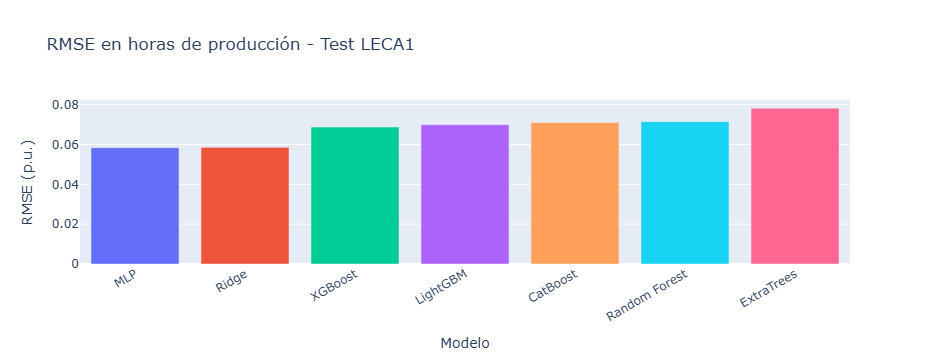

In [8]:
fig = px.bar(
    results_daylight.sort_values("RMSE"),
    x="model", y="RMSE", color="model",
    title="RMSE en horas de producción - Test LECA1",
    labels={"RMSE": "RMSE (p.u.)", "model": "Modelo"},
)
fig.update_layout(showlegend=False, xaxis_tickangle=-30)
fig.show()


### 8. Guardar modelos y resultados
Los modelos se serializan con joblib en `data/models/`. Los resultados
se guardan como CSV en `data/results/` para su uso en notebooks posteriores.


In [9]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

for name, model in trained_models.items():
    model_file = MODELS_DIR / f"{name.replace(' ', '_')}.pkl"
    joblib.dump(model, model_file)

results_val.to_csv(RESULTS_DIR / "results_val_base.csv", index=False)
results_test.to_csv(RESULTS_DIR / "results_test_base.csv", index=False)
results_daylight.to_csv(RESULTS_DIR / "results_test_daylight.csv", index=False)
summary_kw.to_csv(RESULTS_DIR / "results_kw_base.csv", index=False)

print(f"Modelos guardados en: data/models/ ({len(trained_models)} archivos)")
print(f"Resultados guardados en: data/results/")


Modelos guardados en: data/models/ (7 archivos)
Resultados guardados en: data/results/


## Conclusiones del notebook 03

| Modelo | MAE (kW) | RMSE (kW) | R2 | Bias (kW) | MAE_luz (kW) | RMSE_luz (kW) | R2_luz | Bias_luz (kW) |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| MLP | 0.3276 | 0.8563 | 0.9738 | 0.0714 | 0.5662 | 1.1408 | 0.9577 | 0.1334 |
| Ridge | 0.3578 | 0.8694 | 0.9730 | 0.0245 | 0.5916 | 1.1439 | 0.9574 | 0.0269 |
| XGBoost | 0.4817 | 1.0059 | 0.9638 | 0.2474 | 0.8549 | 1.3428 | 0.9413 | 0.4502 |
| LightGBM | 0.4956 | 1.0214 | 0.9627 | 0.2514 | 0.8819 | 1.3659 | 0.9393 | 0.4548 |
| CatBoost | 0.5103 | 1.0378 | 0.9615 | 0.2405 | 0.9061 | 1.3879 | 0.9373 | 0.4370 |
| Random Forest | 0.4753 | 1.0538 | 0.9603 | 0.1959 | 0.8399 | 1.3960 | 0.9366 | 0.3621 |
| ExtraTrees | 0.5504 | 1.1477 | 0.9529 | 0.2325 | 0.9744 | 1.5277 | 0.9241 | 0.4275 |

**Observaciones principales:**
- MLP y Ridge lideran en el test sobre LECA1.
- Los modelos de *boosting* (XGBoost, LightGBM, CatBoost) muestran un sesgo
  positivo en kW, indicando sobrepredicción sistemática en LECA1.
- La métrica en horas de luz es sistemáticamente más exigente, confirmando
  que los ceros nocturnos enmascaran parte del error real.

**Siguiente paso:** análisis de la contribución de la memoria temporal (notebook 04).
